# Projeto 2 — Aprendizado de Máquina: Olist
**Disciplina:** T326 - Ciência dos Dados
**Professor:** Caio Ponte
**Turma:** 16/17

## Resumo
Este notebook implementa um *pipeline* completo de Aprendizado de Máquina sobre o dataset público da **Olist** (e-commerce brasileiro). O objetivo é **prever o tempo (em dias) que um pedido leva para chegar à casa do cliente**, a partir de características extraídas das tabelas de pedidos, itens, produtos, vendedores, clientes e geolocalização.

A estrutura segue exatamente as 5 etapas obrigatórias do enunciado (`docs/Projeto 2 - Aprendizado de Máquina_ Olist.pdf`):
1. Definição do Problema
2. Pré-processamento dos Dados
3. Análise Exploratória dos Dados (EDA)
4. Treinamento do Modelo
5. Avaliação do Modelo e Conclusão


In [1]:
# === Setup: Importação de Bibliotecas ===
# Esta célula carrega todas as bibliotecas usadas ao longo do notebook.
# Centralizar imports facilita a reprodutibilidade e a leitura.

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from category_encoders import TargetEncoder
except ImportError:
    TargetEncoder = None  # fallback opcional; instalar via requirements.txt

# Configurações globais
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


In [2]:
# === Setup: Configuração de Caminhos ===
# Define o diretório onde estão os CSVs do Olist (./dataset relativo à raiz do projeto)
# e valida que todos os arquivos esperados existem antes de prosseguir.

DATA_DIR = Path("./dataset")

ARQUIVOS_ESPERADOS = [
    "olist_customers_dataset.csv",
    "olist_geolocation_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv",
]

faltando = [f for f in ARQUIVOS_ESPERADOS if not (DATA_DIR / f).exists()]
if faltando:
    raise FileNotFoundError(
        f"Arquivos do dataset não encontrados em {DATA_DIR.resolve()}: {faltando}"
    )

print(f"Diretório de dados: {DATA_DIR.resolve()}")
print(f"Todos os {len(ARQUIVOS_ESPERADOS)} arquivos do Olist foram localizados.")


Diretório de dados: C:\Users\User\Desktop\av2 - compt dist\dataset
Todos os 9 arquivos do Olist foram localizados.


## 1. Definição do Problema (PDF Seção 1, Peso 10%)

### Contexto da Olist
A **Olist** é um marketplace brasileiro que conecta pequenos e médios lojistas aos maiores e-commerces do país. Cada pedido envolve um cliente, um ou mais vendedores e operadores logísticos, o que torna o **tempo de entrega** uma métrica crítica para a satisfação do cliente e para o planejamento operacional.

### Problema de Regressão
- **Cada amostra** = um pedido entregue (uma linha por `order_id`).
- **Variável alvo** (contínua): `delivery_time_days` = dias entre `order_purchase_timestamp` e `order_delivered_customer_date`.
- **Tipo de problema:** regressão supervisionada.

### Tabelas utilizadas
- `olist_orders_dataset` — pedidos e timestamps (núcleo do dataset).
- `olist_customers_dataset` — localização do cliente.
- `olist_order_items_dataset` — itens, frete, vendedor.
- `olist_products_dataset` — categoria, peso, dimensões dos produtos.
- `olist_sellers_dataset` — localização do vendedor.
- `olist_geolocation_dataset` — coordenadas (latitude/longitude) por CEP.

Tabelas de pagamento e reviews não são essenciais para a tarefa de **previsão de tempo de entrega** e, portanto, são deixadas de fora do conjunto final.

### Desafio e Impacto
Estimar o tempo de entrega permite **definir prazos realistas para o cliente**, **identificar gargalos logísticos** e **comparar a previsão com o tempo estimado pela própria Olist** (`order_estimated_delivery_date`), apoiando decisões de negócio.


In [3]:
# === Seção 1 — Carregamento das Tabelas Brutas (PDF p.2: identificação das tabelas) ===
# Lê todos os 9 CSVs do Olist em um dicionário para facilitar a inspeção e os merges posteriores.

tabelas = {
    "orders":      pd.read_csv(DATA_DIR / "olist_orders_dataset.csv"),
    "customers":   pd.read_csv(DATA_DIR / "olist_customers_dataset.csv"),
    "order_items": pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv"),
    "products":    pd.read_csv(DATA_DIR / "olist_products_dataset.csv"),
    "sellers":     pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv"),
    "geolocation": pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv"),
    "payments":    pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv"),
    "reviews":     pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv"),
    "categoria":   pd.read_csv(DATA_DIR / "product_category_name_translation.csv"),
}

print("Dimensões das tabelas carregadas:")
for nome, df_ in tabelas.items():
    print(f"  {nome:12s} -> {df_.shape}")


Dimensões das tabelas carregadas:
  orders       -> (99441, 8)
  customers    -> (99441, 5)
  order_items  -> (112650, 7)
  products     -> (32951, 9)
  sellers      -> (3095, 4)
  geolocation  -> (1000163, 5)
  payments     -> (103886, 5)
  reviews      -> (99224, 7)
  categoria    -> (71, 2)


In [4]:
# === Seção 1 — Visão geral do Schema ===
# Para cada tabela, exibe colunas e tipos. Isso confirma quais colunas estão disponíveis
# para engenharia de atributos e identificar campos de timestamp para conversão.

for nome, df_ in tabelas.items():
    print(f"\n=== {nome} ===")
    print(df_.dtypes)



=== orders ===
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

=== customers ===
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

=== order_items ===
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

=== products ===
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_wei

### Relacionamento entre tabelas

```
customers (customer_id)  ─┐
                          ├──> orders (order_id) ──> order_items ──> products
sellers   (seller_id)  ───┘                                ↑
                                                           │
geolocation (zip_code_prefix)  attaches lat/lng to customers e sellers
```

**Justificativa da escolha:**
- `orders` traz os timestamps que definem a variável alvo.
- `order_items` permite agregar quantidade de itens, preço total e frete por pedido.
- `products` adiciona características físicas (peso/volume) que afetam o frete.
- `customers` + `sellers` + `geolocation` permitem calcular a **distância geográfica** cliente↔vendedor, fortemente correlacionada com o tempo de entrega.


## 2. Pré-processamento dos Dados (PDF Seção 2, Peso 30%)

Cobrimos **todos os 5 sub-requisitos** do PDF (rubrica exige ao menos 4):
1. Engenharia de atributos
2. Filtragem e limpeza
3. Tratamento de valores faltantes
4. Normalização / padronização
5. Tratamento de variáveis categóricas


In [5]:
# === Seção 2.1 — Filtragem: manter apenas pedidos entregues (PDF p.2: limpeza) ===
# A variável alvo só faz sentido para pedidos entregues. Removemos status diferentes
# e linhas sem timestamp de entrega ao cliente.

orders = tabelas["orders"].copy()
print(f"Antes da filtragem: {orders.shape}")

orders = orders[orders["order_status"] == "delivered"].copy()
orders = orders.dropna(subset=["order_delivered_customer_date", "order_purchase_timestamp"])

print(f"Após filtrar entregues e timestamps válidos: {orders.shape}")


Antes da filtragem: (99441, 8)
Após filtrar entregues e timestamps válidos: (96470, 8)


In [6]:
# === Seção 2.1 — Conversão de Datas ===
# Converte todas as colunas temporais para datetime para permitir cálculos de diferença.

colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in colunas_data:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print(orders[colunas_data].dtypes)


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [7]:
# === Seção 2.1 — Construção da Variável Alvo ===
# delivery_time_days = (entrega ao cliente) - (compra), em dias (float).
# Removemos valores patológicos (negativos ou zero) que indicam erro de registro.

orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0

antes = len(orders)
orders = orders[orders["delivery_time_days"] > 0].copy()
print(f"Linhas removidas com tempo <= 0: {antes - len(orders)}")
print(orders["delivery_time_days"].describe())


Linhas removidas com tempo <= 0: 0
count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_time_days, dtype: float64


In [8]:
# === Seção 2.1 — Engenharia de Atributos: Nível Pedido (PDF p.2: feature engineering) ===
# Variáveis temporais derivadas da data de compra e da data estimada pela Olist.

orders["purchase_dow"]   = orders["order_purchase_timestamp"].dt.dayofweek      # 0 = segunda
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month
orders["purchase_hour"]  = orders["order_purchase_timestamp"].dt.hour

orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0

orders["approval_delay_hours"] = (
    orders["order_approved_at"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600.0

print(orders[["purchase_dow", "purchase_month", "purchase_hour",
              "estimated_delivery_days", "approval_delay_hours"]].head())


   purchase_dow  purchase_month  purchase_hour  estimated_delivery_days  approval_delay_hours
0             0              10             10                15.544063              0.178333
1             1               7             20                19.137766             30.713889
2             2               8              8                26.639711              0.276111
3             5              11             19                26.188819              0.298056
4             1               2             21                12.112049              1.030556


In [9]:
# === Seção 2.1 — Engenharia de Atributos: Agregação de Itens ===
# Cada pedido pode ter múltiplos itens. Agregamos por order_id para uma única linha por pedido.

itens = tabelas["order_items"].copy()

agg_itens = itens.groupby("order_id").agg(
    n_items       = ("order_item_id", "count"),
    n_sellers     = ("seller_id", "nunique"),
    total_price   = ("price", "sum"),
    total_freight = ("freight_value", "sum"),
).reset_index()

agg_itens["freight_ratio"] = (
    agg_itens["total_freight"] / agg_itens["total_price"].replace(0, np.nan)
)

print(agg_itens.head())
print(f"Linhas: {len(agg_itens)}")


                           order_id  n_items  n_sellers  total_price  total_freight  freight_ratio
0  00010242fe8c5a6d1ba2dd792cb16214        1          1        58.90          13.29       0.225637
1  00018f77f2f0320c557190d7a144bdd3        1          1       239.90          19.93       0.083076
2  000229ec398224ef6ca0657da4fc703e        1          1       199.00          17.87       0.089799
3  00024acbcdf0a6daa1e931b038114c75        1          1        12.99          12.79       0.984604
4  00042b26cf59d7ce69dfabb4e55b4fd9        1          1       199.90          18.14       0.090745
Linhas: 98666


In [10]:
# === Seção 2.1 — Engenharia de Atributos: Informações de Produto ===
# Junta dados de produto a cada item e agrega métricas físicas/categoria por pedido.

produtos = tabelas["products"].copy()
produtos["product_volume_cm3"] = (
    produtos["product_length_cm"]
    * produtos["product_height_cm"]
    * produtos["product_width_cm"]
)

itens_prod = itens.merge(
    produtos[[
        "product_id", "product_category_name", "product_weight_g",
        "product_volume_cm3", "product_photos_qty",
        "product_name_lenght", "product_description_lenght",
    ]],
    on="product_id", how="left",
)

agg_prod = itens_prod.groupby("order_id").agg(
    max_product_weight   = ("product_weight_g", "max"),
    total_product_volume = ("product_volume_cm3", "sum"),
    avg_photos_qty       = ("product_photos_qty", "mean"),
    avg_name_length      = ("product_name_lenght", "mean"),
    avg_desc_length      = ("product_description_lenght", "mean"),
    # Para a categoria, pegamos a categoria do primeiro item (proxy razoável)
    product_category     = ("product_category_name", "first"),
).reset_index()

print(agg_prod.head())


                           order_id  max_product_weight  total_product_volume  avg_photos_qty  avg_name_length  avg_desc_length    product_category
0  00010242fe8c5a6d1ba2dd792cb16214               650.0                3528.0             4.0             58.0            598.0          cool_stuff
1  00018f77f2f0320c557190d7a144bdd3             30000.0               60000.0             2.0             56.0            239.0            pet_shop
2  000229ec398224ef6ca0657da4fc703e              3050.0               14157.0             2.0             59.0            695.0    moveis_decoracao
3  00024acbcdf0a6daa1e931b038114c75               200.0                2400.0             1.0             42.0            480.0          perfumaria
4  00042b26cf59d7ce69dfabb4e55b4fd9              3750.0               42000.0             1.0             59.0            409.0  ferramentas_jardim


In [11]:
# === Seção 2.1 — Engenharia de Atributos: Geolocalização ===
# Calcula lat/lng médias por prefixo de CEP, anexa coordenadas a clientes e vendedores
# e calcula a distância Haversine cliente <-> vendedor (forte preditor de tempo de entrega).

geo = tabelas["geolocation"].copy()
geo_agg = geo.groupby("geolocation_zip_code_prefix").agg(
    lat=("geolocation_lat", "mean"),
    lng=("geolocation_lng", "mean"),
).reset_index().rename(columns={"geolocation_zip_code_prefix": "zip_prefix"})

# Coordenadas dos clientes
customers = tabelas["customers"][["customer_id", "customer_zip_code_prefix", "customer_state"]].copy()
customers = customers.merge(
    geo_agg.rename(columns={"zip_prefix": "customer_zip_code_prefix",
                             "lat": "customer_lat", "lng": "customer_lng"}),
    on="customer_zip_code_prefix", how="left",
)

# Coordenadas dos vendedores (pegamos o primeiro vendedor de cada pedido)
sellers = tabelas["sellers"][["seller_id", "seller_zip_code_prefix", "seller_state"]].copy()
sellers = sellers.merge(
    geo_agg.rename(columns={"zip_prefix": "seller_zip_code_prefix",
                             "lat": "seller_lat", "lng": "seller_lng"}),
    on="seller_zip_code_prefix", how="left",
)
primeiro_seller = itens.sort_values("order_item_id").drop_duplicates("order_id")[["order_id", "seller_id"]]
seller_por_pedido = primeiro_seller.merge(sellers, on="seller_id", how="left")


def haversine_km(lat1, lon1, lat2, lon2):
    """Distância em quilômetros entre dois pontos (lat, lng) na superfície da Terra."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


print("Geolocalização preparada. Distância será calculada após o merge final.")


Geolocalização preparada. Distância será calculada após o merge final.


In [12]:
# === Seção 2.1 — Master Merge ===
# Junta orders + customers + agregação de itens + agregação de produtos + geolocalização
# em um único DataFrame plano (uma linha por pedido).

df = (
    orders[[
        "order_id", "customer_id", "delivery_time_days",
        "purchase_dow", "purchase_month", "purchase_hour",
        "estimated_delivery_days", "approval_delay_hours",
    ]]
    .merge(customers, on="customer_id", how="left")
    .merge(agg_itens, on="order_id", how="left")
    .merge(agg_prod, on="order_id", how="left")
    .merge(seller_por_pedido[["order_id", "seller_state", "seller_lat", "seller_lng"]],
           on="order_id", how="left")
)

# Distância Haversine cliente <-> vendedor
df["customer_seller_distance_km"] = haversine_km(
    df["customer_lat"], df["customer_lng"], df["seller_lat"], df["seller_lng"]
)

print(f"Shape final do DataFrame: {df.shape}")
print(f"Colunas: {list(df.columns)}")


Shape final do DataFrame: (96470, 27)
Colunas: ['order_id', 'customer_id', 'delivery_time_days', 'purchase_dow', 'purchase_month', 'purchase_hour', 'estimated_delivery_days', 'approval_delay_hours', 'customer_zip_code_prefix', 'customer_state', 'customer_lat', 'customer_lng', 'n_items', 'n_sellers', 'total_price', 'total_freight', 'freight_ratio', 'max_product_weight', 'total_product_volume', 'avg_photos_qty', 'avg_name_length', 'avg_desc_length', 'product_category', 'seller_state', 'seller_lat', 'seller_lng', 'customer_seller_distance_km']


In [13]:
# === Seção 2.2 — Filtragem de Outliers / Ruído (PDF p.2: limpeza) ===
# Tempos de entrega extremamente longos (> 99º percentil) provavelmente indicam casos
# atípicos (greve, devolução, registro tardio) e prejudicariam o aprendizado.

q99 = df["delivery_time_days"].quantile(0.99)
print(f"99º percentil do tempo de entrega: {q99:.1f} dias")

antes = len(df)
df = df[df["delivery_time_days"] <= q99].copy()
print(f"Linhas removidas (cap em 99º percentil): {antes - len(df)}")
print(f"Shape após corte de outliers: {df.shape}")


99º percentil do tempo de entrega: 46.1 dias
Linhas removidas (cap em 99º percentil): 965
Shape após corte de outliers: (95505, 27)


In [14]:
# === Seção 2.3 — Tratamento de Valores Faltantes (PDF p.2: SimpleImputer / KNNImputer) ===
# Diagnóstico antes de imputar: quanto cada coluna possui de valores nulos?

faltantes = df.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
print("Valores faltantes por coluna:")
print(faltantes)

# Estratégia adotada (a imputação numérica de fato é feita pelo ColumnTransformer mais adiante):
# - Numéricas -> SimpleImputer(strategy='median'), robusto a assimetria e outliers.
# - Categóricas -> SimpleImputer(strategy='most_frequent').
# - Demonstração: KNNImputer aplicado a uma amostra para ilustrar a técnica alternativa.

amostra_numerica = df.select_dtypes(include="number").drop(columns=["delivery_time_days"]).head(2000)
demo_knn = KNNImputer(n_neighbors=5).fit_transform(amostra_numerica)
print(f"\nKNNImputer demonstrado em amostra de shape {amostra_numerica.shape} -> saída {demo_knn.shape}")
print("A imputação final será aplicada via ColumnTransformer (Seção 2.6).")


Valores faltantes por coluna:
avg_name_length                1324
avg_desc_length                1324
product_category               1324
avg_photos_qty                 1324
customer_seller_distance_km     469
customer_lng                    257
customer_lat                    257
seller_lng                      213
seller_lat                      213
max_product_weight               16
approval_delay_hours             14
dtype: int64

KNNImputer demonstrado em amostra de shape (2000, 21) -> saída (2000, 21)
A imputação final será aplicada via ColumnTransformer (Seção 2.6).


In [15]:
# === Seção 2.4 — Tratamento de Variáveis Categóricas (PDF p.2: OneHot / Target Encoder) ===
# Lista de colunas categóricas e estratégia por cardinalidade.

colunas_categoricas = ["customer_state", "seller_state", "product_category"]

for c in colunas_categoricas:
    print(f"{c}: cardinalidade = {df[c].nunique()}")

# Estratégia:
# - product_category (alta cardinalidade ~74) -> TargetEncoder se disponível, senão OneHot
# - customer_state / seller_state (27 ufs) -> OneHotEncoder
# A montagem é feita no ColumnTransformer (Seção 2.6) para evitar vazamento de dados.


customer_state: cardinalidade = 27
seller_state: cardinalidade = 22
product_category: cardinalidade = 73


In [16]:
# === Seção 2.5 — Normalização / Padronização (PDF p.2: RobustScaler / Log) ===
# Variáveis monetárias e de distância são tipicamente assimétricas (cauda longa).
# Aplicamos log1p (FunctionTransformer) e depois RobustScaler para neutralizar outliers.

colunas_log = ["total_price", "total_freight", "customer_seller_distance_km",
               "max_product_weight", "total_product_volume"]
colunas_numericas_padrao = [
    "purchase_dow", "purchase_month", "purchase_hour",
    "estimated_delivery_days", "approval_delay_hours",
    "n_items", "n_sellers", "freight_ratio",
    "avg_photos_qty", "avg_name_length", "avg_desc_length",
]

print(f"Colunas com log1p + RobustScaler: {colunas_log}")
print(f"Colunas com apenas RobustScaler: {colunas_numericas_padrao}")


Colunas com log1p + RobustScaler: ['total_price', 'total_freight', 'customer_seller_distance_km', 'max_product_weight', 'total_product_volume']
Colunas com apenas RobustScaler: ['purchase_dow', 'purchase_month', 'purchase_hour', 'estimated_delivery_days', 'approval_delay_hours', 'n_items', 'n_sellers', 'freight_ratio', 'avg_photos_qty', 'avg_name_length', 'avg_desc_length']


In [17]:
# === Seção 2.6 — Construção do ColumnTransformer ===
# Reúne imputação + escala + codificação em um único objeto reutilizável.
# Encaixar tudo em um Pipeline impede vazamento de dados entre treino e teste.

pipe_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log",     FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler",  RobustScaler()),
])

pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("log", pipe_log, colunas_log),
        ("num", pipe_num, colunas_numericas_padrao),
        ("cat", pipe_cat, colunas_categoricas),
    ],
    remainder="drop",
)

print("ColumnTransformer construído com 3 ramos: log, num, cat.")


ColumnTransformer construído com 3 ramos: log, num, cat.


In [18]:
# === Seção 2.7 — Resumo das Features Selecionadas (PDF p.2: REQUERIDO) ===
# Tabela explicativa de todas as features e como cada uma é tratada.

resumo_features = pd.DataFrame([
    # Numéricas com log1p
    ("total_price",                "numérica", "log1p + RobustScaler", "Valor total dos itens do pedido"),
    ("total_freight",              "numérica", "log1p + RobustScaler", "Valor total do frete"),
    ("customer_seller_distance_km","numérica", "log1p + RobustScaler", "Distância Haversine cliente-vendedor"),
    ("max_product_weight",         "numérica", "log1p + RobustScaler", "Peso máximo entre os produtos do pedido"),
    ("total_product_volume",       "numérica", "log1p + RobustScaler", "Volume total dos produtos do pedido"),
    # Numéricas padrão
    ("purchase_dow",          "numérica", "RobustScaler", "Dia da semana da compra"),
    ("purchase_month",        "numérica", "RobustScaler", "Mês da compra"),
    ("purchase_hour",         "numérica", "RobustScaler", "Hora da compra"),
    ("estimated_delivery_days","numérica","RobustScaler", "Prazo estimado pela Olist em dias"),
    ("approval_delay_hours",  "numérica", "RobustScaler", "Horas entre compra e aprovação"),
    ("n_items",               "numérica", "RobustScaler", "Quantidade de itens no pedido"),
    ("n_sellers",             "numérica", "RobustScaler", "Vendedores únicos no pedido"),
    ("freight_ratio",         "numérica", "RobustScaler", "Frete dividido pelo preço total"),
    ("avg_photos_qty",        "numérica", "RobustScaler", "Média de fotos por produto"),
    ("avg_name_length",       "numérica", "RobustScaler", "Tamanho médio do nome do produto"),
    ("avg_desc_length",       "numérica", "RobustScaler", "Tamanho médio da descrição do produto"),
    # Categóricas
    ("customer_state",   "categórica", "OneHotEncoder", "UF do cliente"),
    ("seller_state",     "categórica", "OneHotEncoder", "UF do vendedor"),
    ("product_category", "categórica", "OneHotEncoder", "Categoria do primeiro produto"),
], columns=["feature", "tipo", "transformação", "descrição"])

print(resumo_features.to_string(index=False))
print(f"\nTotal de features: {len(resumo_features)}")
df.describe(include='all').T.head(40)


                    feature       tipo        transformação                               descrição
                total_price   numérica log1p + RobustScaler         Valor total dos itens do pedido
              total_freight   numérica log1p + RobustScaler                    Valor total do frete
customer_seller_distance_km   numérica log1p + RobustScaler    Distância Haversine cliente-vendedor
         max_product_weight   numérica log1p + RobustScaler Peso máximo entre os produtos do pedido
       total_product_volume   numérica log1p + RobustScaler     Volume total dos produtos do pedido
               purchase_dow   numérica         RobustScaler                 Dia da semana da compra
             purchase_month   numérica         RobustScaler                           Mês da compra
              purchase_hour   numérica         RobustScaler                          Hora da compra
    estimated_delivery_days   numérica         RobustScaler       Prazo estimado pela Olist em dias


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,95505,95505,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,95505,95505,9ef432eb6251297304e76186b10a928d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_time_days,95505.0,NaN,NaN,NaN,12.052942,7.740056,0.533414,6.722731,10.154329,15.369306,46.048461
purchase_dow,95505.0,NaN,NaN,NaN,2.755405,1.967444,0.0,1.0,3.0,4.0,6.0
purchase_month,95505.0,NaN,NaN,NaN,6.038689,3.220605,1.0,3.0,6.0,8.0,12.0
purchase_hour,95505.0,NaN,NaN,NaN,14.773959,5.32606,0.0,11.0,15.0,19.0,23.0
estimated_delivery_days,95505.0,NaN,NaN,NaN,23.66893,8.70821,2.008009,18.291933,23.196458,28.371655,155.135463
approval_delay_hours,95491.0,NaN,NaN,NaN,10.257906,20.400063,0.0,0.215278,0.343056,14.474028,741.443611
customer_zip_code_prefix,95505.0,NaN,NaN,NaN,35118.328433,29874.003411,1003.0,11088.0,24350.0,58920.0,99980.0
customer_state,95505,27,SP,40377,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Análise Exploratória dos Dados — EDA (PDF Seção 3, Peso 10%)

Cobrimos **todos os 5 sub-requisitos**: distribuições, outliers, correlações, estatísticas descritivas e mapas geográficos.


In [19]:
# === Seção 3.1 — Estatísticas Descritivas (PDF p.3) ===
# Resumo estatístico para colunas numéricas e contagens para categóricas.

print("=== Numéricas ===")
print(df.describe().T)

print("\n=== Categóricas ===")
print(df.describe(include='object').T)


=== Numéricas ===
                               count          mean           std          min           25%           50%           75%           max
delivery_time_days           95505.0     12.052942      7.740056     0.533414      6.722731     10.154329     15.369306  4.604846e+01
purchase_dow                 95505.0      2.755405      1.967444     0.000000      1.000000      3.000000      4.000000  6.000000e+00
purchase_month               95505.0      6.038689      3.220605     1.000000      3.000000      6.000000      8.000000  1.200000e+01
purchase_hour                95505.0     14.773959      5.326060     0.000000     11.000000     15.000000     19.000000  2.300000e+01
estimated_delivery_days      95505.0     23.668930      8.708210     2.008009     18.291933     23.196458     28.371655  1.551355e+02
approval_delay_hours         95491.0     10.257906     20.400063     0.000000      0.215278      0.343056     14.474028  7.414436e+02
customer_zip_code_prefix     95505.0  35118.

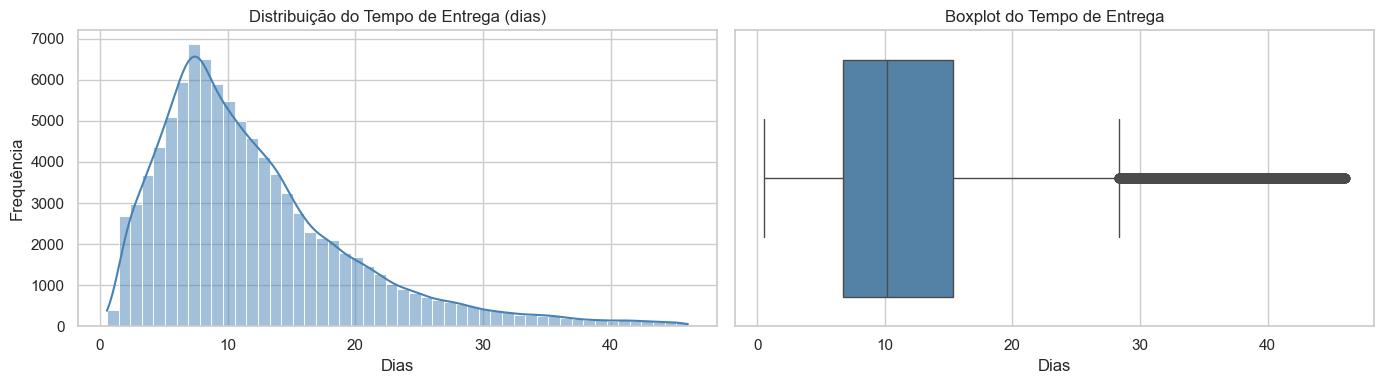

Média: 12.05 dias
Mediana: 10.15 dias
Desvio padrão: 7.74 dias


In [20]:
# === Seção 3.2 — Distribuição da Variável Alvo (PDF p.3) ===
# Histograma + boxplot para entender a assimetria do tempo de entrega.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["delivery_time_days"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição do Tempo de Entrega (dias)")
axes[0].set_xlabel("Dias")
axes[0].set_ylabel("Frequência")

sns.boxplot(x=df["delivery_time_days"], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot do Tempo de Entrega")
axes[1].set_xlabel("Dias")

plt.tight_layout()
plt.show()

print(f"Média: {df['delivery_time_days'].mean():.2f} dias")
print(f"Mediana: {df['delivery_time_days'].median():.2f} dias")
print(f"Desvio padrão: {df['delivery_time_days'].std():.2f} dias")


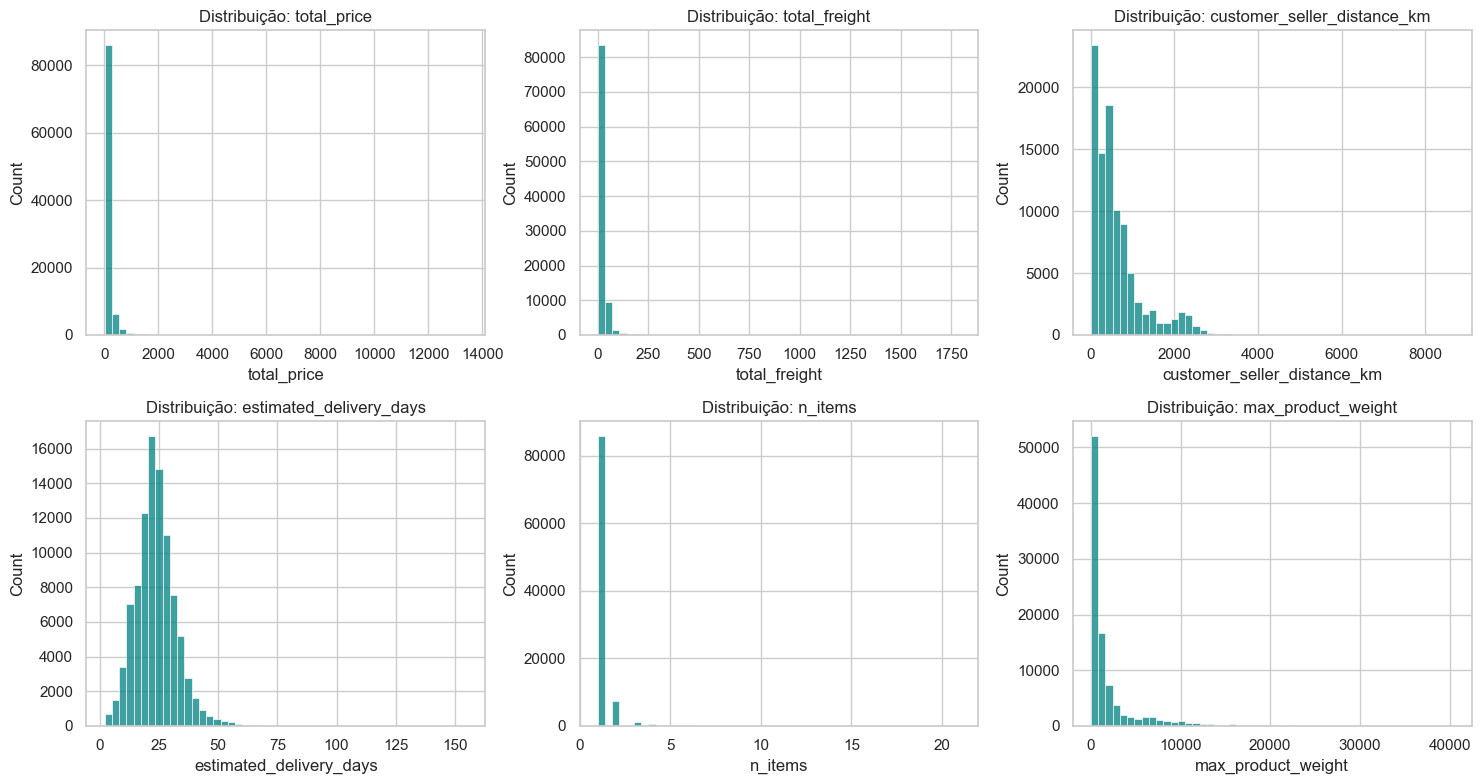

In [21]:
# === Seção 3.2 — Distribuição das Features Numéricas ===
# Grade de histogramas para inspecionar assimetria e necessidade de transformações.

features_plot = [
    "total_price", "total_freight", "customer_seller_distance_km",
    "estimated_delivery_days", "n_items", "max_product_weight",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, features_plot):
    sns.histplot(df[col].dropna(), bins=50, ax=ax, color="teal")
    ax.set_title(f"Distribuição: {col}")
plt.tight_layout()
plt.show()


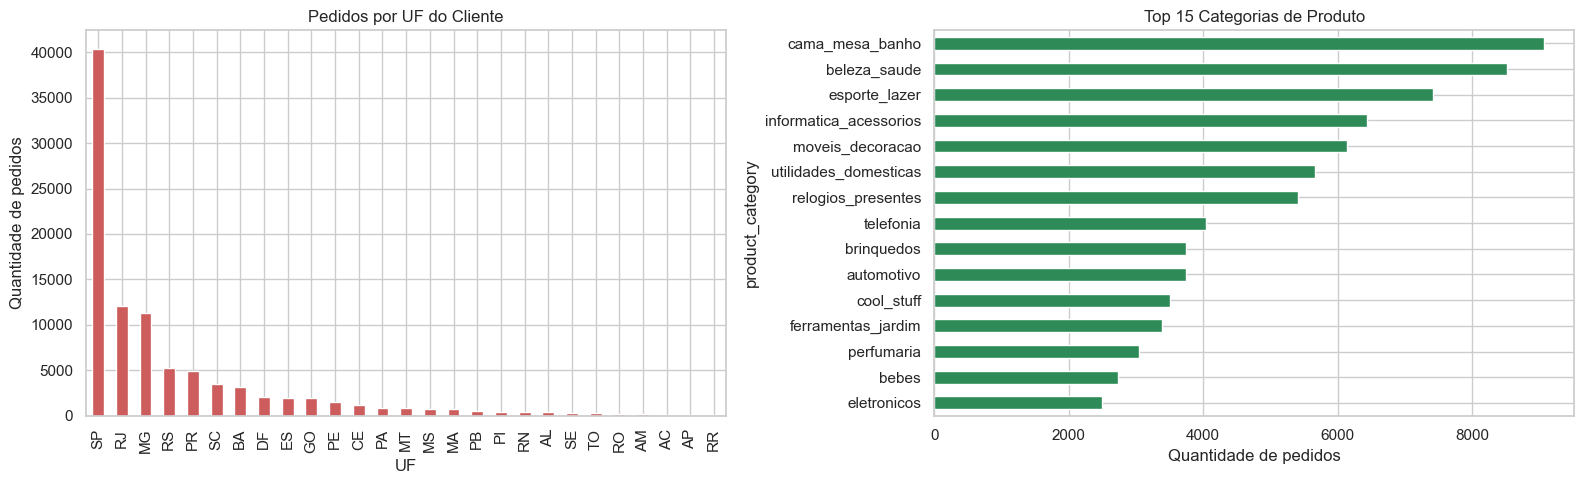

In [22]:
# === Seção 3.2 — Distribuição das Features Categóricas ===
# Top categorias por frequência: clientes por estado e top 15 categorias de produto.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df["customer_state"].value_counts().plot(kind="bar", ax=axes[0], color="indianred")
axes[0].set_title("Pedidos por UF do Cliente")
axes[0].set_xlabel("UF")
axes[0].set_ylabel("Quantidade de pedidos")

df["product_category"].value_counts().head(15).plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Top 15 Categorias de Produto")
axes[1].set_xlabel("Quantidade de pedidos")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


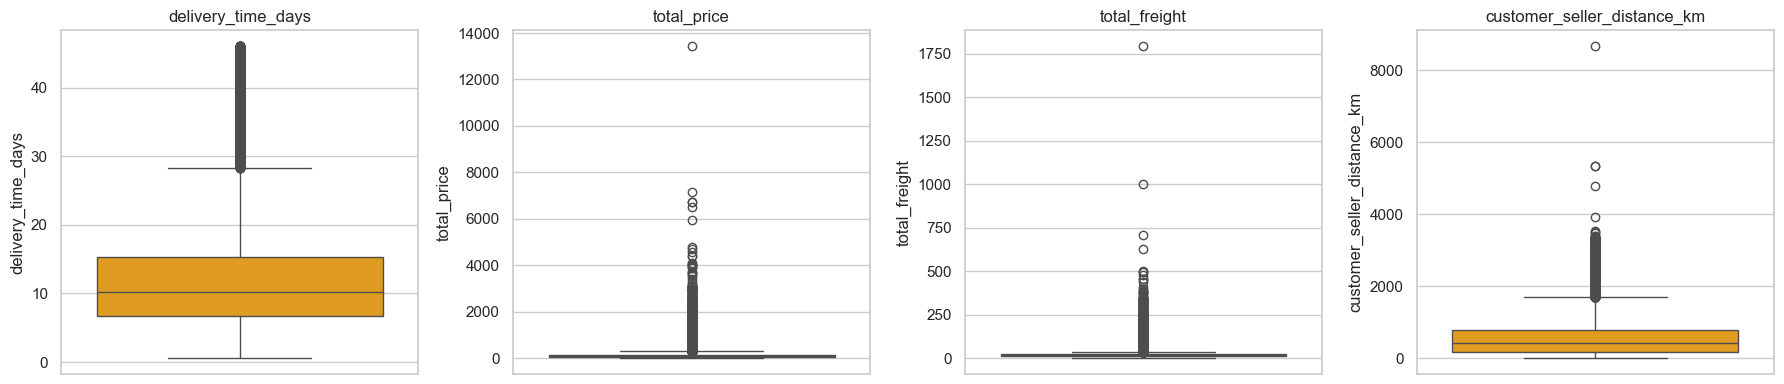

                        coluna  outliers (IQR)
0           delivery_time_days            4370
1                  total_price            7537
2                total_freight            9588
3  customer_seller_distance_km            7212


In [23]:
# === Seção 3.3 — Identificação de Outliers (PDF p.3) ===
# Boxplots em variáveis numéricas críticas e contagem por IQR.

cols_outlier = ["delivery_time_days", "total_price", "total_freight", "customer_seller_distance_km"]
fig, axes = plt.subplots(1, len(cols_outlier), figsize=(18, 4))
for ax, c in zip(axes, cols_outlier):
    sns.boxplot(y=df[c], ax=ax, color="orange")
    ax.set_title(c)
plt.tight_layout()
plt.show()

# Contagem de outliers via IQR
def conta_outliers_iqr(s: pd.Series):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

tabela_iqr = pd.DataFrame({
    "coluna": cols_outlier,
    "outliers (IQR)": [conta_outliers_iqr(df[c].dropna()) for c in cols_outlier],
})
print(tabela_iqr)


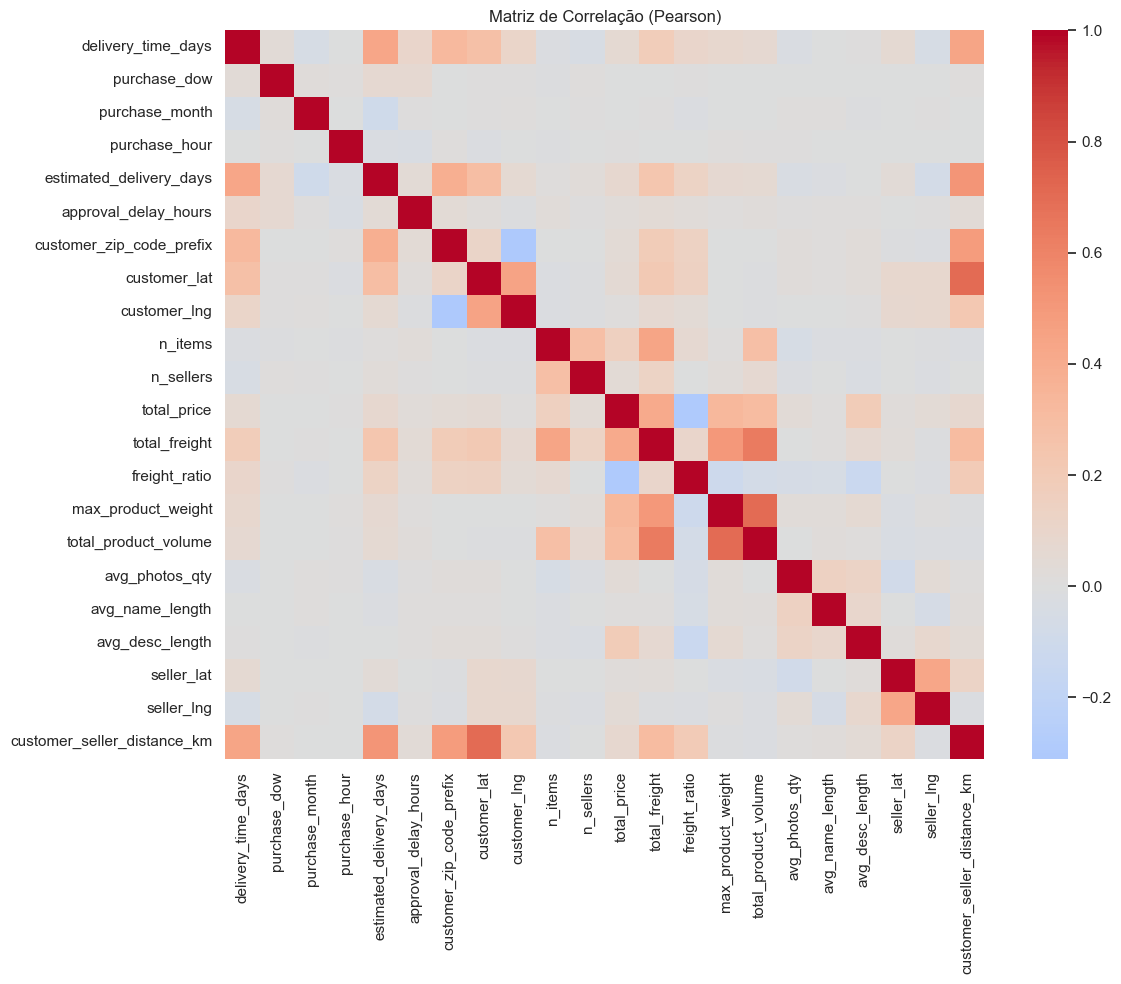


Top correlações com delivery_time_days:
customer_seller_distance_km    0.441823
estimated_delivery_days        0.431923
customer_zip_code_prefix       0.321111
customer_lat                   0.278378
total_freight                  0.185314
customer_lng                   0.108074
freight_ratio                  0.097388
approval_delay_hours           0.096433
max_product_weight             0.079047
total_product_volume           0.064503
seller_lat                     0.062431
total_price                    0.055186
purchase_month                -0.050720
seller_lng                    -0.046515
n_sellers                     -0.043336
Name: delivery_time_days, dtype: float64


In [24]:
# === Seção 3.4 — Matriz de Correlações (PDF p.3) ===
# Heatmap das correlações de Pearson entre numéricas e listagem das mais ligadas ao alvo.

num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de Correlação (Pearson)")
plt.tight_layout()
plt.show()

print("\nTop correlações com delivery_time_days:")
print(corr["delivery_time_days"].drop("delivery_time_days").sort_values(key=abs, ascending=False).head(15))


In [25]:
# === Seção 3.5 — Mapa Geográfico: Tempo Médio por UF (PDF p.3: lat/lng) ===
# Visualização espacial via Plotly: scatter dos clientes colorido pelo tempo médio de entrega.

amostra_geo = df.dropna(subset=["customer_lat", "customer_lng"]).sample(
    n=min(15000, len(df)), random_state=SEED
)

fig = px.scatter_mapbox(
    amostra_geo,
    lat="customer_lat",
    lon="customer_lng",
    color="delivery_time_days",
    color_continuous_scale="Viridis",
    range_color=(0, amostra_geo["delivery_time_days"].quantile(0.95)),
    zoom=3,
    height=550,
    title="Tempo de Entrega (dias) por Localização do Cliente",
)
fig.update_layout(mapbox_style="open-street-map", margin=dict(l=0, r=0, t=40, b=0))
fig.show()


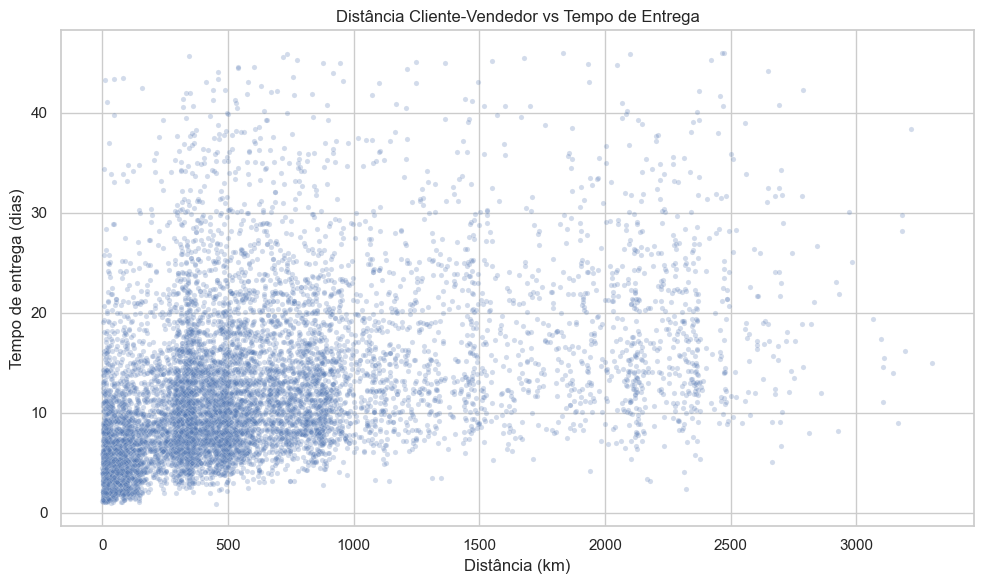

In [26]:
# === Seção 3.5 — Relação entre Distância e Tempo de Entrega ===
# Scatter (com amostragem) para visualizar a relação distância x tempo de entrega.

amostra = df.dropna(subset=["customer_seller_distance_km"]).sample(
    n=min(10000, len(df)), random_state=SEED
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=amostra,
    x="customer_seller_distance_km",
    y="delivery_time_days",
    alpha=0.25,
    s=14,
)
plt.title("Distância Cliente-Vendedor vs Tempo de Entrega")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de entrega (dias)")
plt.tight_layout()
plt.show()


### Insights da EDA

- **Tempo de entrega** apresenta forte assimetria à direita: a maioria dos pedidos chega em até 15 dias, mas há cauda longa.
- **Distância cliente-vendedor** correlaciona positivamente com tempo de entrega — relação não-linear.
- **Estimated delivery days** (prazo informado pela Olist) é provavelmente uma das features mais informativas — esperamos que apareça com alta importância nos modelos baseados em árvore.
- **Variáveis monetárias** (preço, frete) são fortemente assimétricas, justificando o `log1p` aplicado no pré-processamento.
- **Variação geográfica** é marcante: estados do Norte/Nordeste tendem a ter tempos médios maiores que SP/RJ.


## 4. Treinamento do Modelo (PDF Seção 4, Peso 30%)

Cobrimos **todos os sub-requisitos**:
- Separação treino/teste + validação cruzada (KFold de 5 *folds*).
- **Quatro modelos** (rubrica exige ao menos três): Ridge (linear), Random Forest (ensemble de árvores), Gradient Boosting (ensemble), KNN (instâncias).
- Ajuste de hiperparâmetros via **GridSearchCV** e **RandomizedSearchCV**.


In [27]:
# === Seção 4.1 — Separação Treino/Teste (PDF p.3) ===
# Define X (features) e y (alvo) e separa 80/20 com seed fixa para reprodutibilidade.

features = colunas_log + colunas_numericas_padrao + colunas_categoricas

X = df[features].copy()
y = df["delivery_time_days"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


X_train: (76404, 19), X_test: (19101, 19)
y_train: (76404,), y_test: (19101,)


In [28]:
# === Seção 4.1 — Esquema de Validação Cruzada ===
# KFold de 5 dobras, embaralhado, para uso consistente em todos os tunings.

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(cv)


KFold(n_splits=5, random_state=42, shuffle=True)


In [29]:
# === Seção 4.2 — Modelo A: Linear Ridge (PDF p.3: modelos lineares) ===
# Pipeline com pré-processamento + Ridge regressão, baseline rápida.

pipe_ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(random_state=SEED)),
])

scores = cross_val_score(pipe_ridge, X_train, y_train,
                         scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
print(f"Ridge (default) - RMSE CV: {-scores.mean():.3f} (+/- {scores.std():.3f})")


Ridge (default) - RMSE CV: 6.403 (+/- 0.040)


In [30]:
# === Seção 4.3 — Tuning Ridge: GridSearchCV (PDF p.3) ===
# Busca exaustiva sobre o parâmetro de regularização alpha.

grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid={"model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_
print(f"Melhor alpha: {grid_ridge.best_params_}")
print(f"Melhor RMSE CV: {-grid_ridge.best_score_:.3f}")


Fitting 5 folds for each of 7 candidates, totalling 35 fits
Melhor alpha: {'model__alpha': 10.0}
Melhor RMSE CV: 6.402


In [31]:
# === Seção 4.2 — Modelo B: Random Forest (PDF p.3: árvores / ensembles) ===
# Pipeline com pré-processamento + Random Forest. Robusto a não-linearidades e interações.

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1)),
])

scores = cross_val_score(pipe_rf, X_train, y_train,
                         scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
print(f"Random Forest (default) - RMSE CV: {-scores.mean():.3f} (+/- {scores.std():.3f})")


Random Forest (default) - RMSE CV: 5.987 (+/- 0.024)


In [32]:
# === Seção 4.3 — Tuning Random Forest: RandomizedSearchCV (PDF p.3) ===
# Busca aleatória mais barata que grid completo, em um espaço de hiperparâmetros amplo.

random_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions={
        "model__n_estimators":      [100, 200, 400],
        "model__max_depth":         [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features":      ["sqrt", "log2", 0.5],
    },
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)
random_rf.fit(X_train, y_train)

best_rf = random_rf.best_estimator_
print(f"Melhores parâmetros RF: {random_rf.best_params_}")
print(f"Melhor RMSE CV: {-random_rf.best_score_:.3f}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhores parâmetros RF: {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__max_features': 0.5, 'model__max_depth': 20}
Melhor RMSE CV: 5.915


In [33]:
# === Seção 4.2 — Modelo C: Gradient Boosting (PDF p.3: ensembles) ===
# GradientBoostingRegressor: um dos algoritmos mais fortes para tabular regressão.

pipe_gb = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(random_state=SEED)),
])

scores = cross_val_score(pipe_gb, X_train, y_train,
                         scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
print(f"Gradient Boosting (default) - RMSE CV: {-scores.mean():.3f} (+/- {scores.std():.3f})")


Gradient Boosting (default) - RMSE CV: 6.054 (+/- 0.028)


In [34]:
# === Seção 4.3 — Tuning Gradient Boosting: RandomizedSearchCV ===
# Busca aleatória sobre learning_rate, n_estimators e max_depth.

random_gb = RandomizedSearchCV(
    pipe_gb,
    param_distributions={
        "model__n_estimators":  [100, 200, 400],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth":     [2, 3, 4, 5],
        "model__subsample":     [0.7, 0.85, 1.0],
    },
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)
random_gb.fit(X_train, y_train)

best_gb = random_gb.best_estimator_
print(f"Melhores parâmetros GB: {random_gb.best_params_}")
print(f"Melhor RMSE CV: {-random_gb.best_score_:.3f}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhores parâmetros GB: {'model__subsample': 0.85, 'model__n_estimators': 400, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Melhor RMSE CV: 5.910


In [35]:
# === Seção 4.2 — Modelo D: KNN (PDF p.3: modelos baseados em instâncias) ===
# KNN serve como um quarto modelo (rubrica exige >= 3) e tuning rápido por GridSearchCV.

pipe_knn = Pipeline([
    ("prep", preprocessor),
    ("model", KNeighborsRegressor(n_jobs=-1)),
])

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid={
        "model__n_neighbors": [5, 10, 20],
        "model__weights":     ["uniform", "distance"],
    },
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
print(f"Melhores parâmetros KNN: {grid_knn.best_params_}")
print(f"Melhor RMSE CV: {-grid_knn.best_score_:.3f}")


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros KNN: {'model__n_neighbors': 20, 'model__weights': 'distance'}
Melhor RMSE CV: 6.335


In [36]:
# === Seção 4.4 — Resumo dos Tunings ===
# Tabela comparativa dos melhores hiperparâmetros e RMSE de validação cruzada.

resumo_tuning = pd.DataFrame([
    {"modelo": "Ridge",             "rmse_cv": -grid_ridge.best_score_,  "params": grid_ridge.best_params_},
    {"modelo": "Random Forest",     "rmse_cv": -random_rf.best_score_,   "params": random_rf.best_params_},
    {"modelo": "Gradient Boosting", "rmse_cv": -random_gb.best_score_,   "params": random_gb.best_params_},
    {"modelo": "KNN",               "rmse_cv": -grid_knn.best_score_,    "params": grid_knn.best_params_},
]).sort_values("rmse_cv").reset_index(drop=True)

print(resumo_tuning.to_string(index=False))


           modelo  rmse_cv                                                                                                          params
Gradient Boosting 5.910024      {'model__subsample': 0.85, 'model__n_estimators': 400, 'model__max_depth': 4, 'model__learning_rate': 0.1}
    Random Forest 5.914724 {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__max_features': 0.5, 'model__max_depth': 20}
              KNN 6.334956                                                        {'model__n_neighbors': 20, 'model__weights': 'distance'}
            Ridge 6.402140                                                                                          {'model__alpha': 10.0}


### Discussão dos Tunings
- **Ridge** serve como baseline linear: rápido, mas tende a perder relações não-lineares (ex.: distância x tempo).
- **Random Forest** se beneficia de profundidade controlada e número moderado de árvores; tende a estabilizar com `n_estimators >= 200`.
- **Gradient Boosting** costuma vencer em performance, mas é o mais sensível a `learning_rate` x `n_estimators`.
- **KNN** é o mais lento na inferência e geralmente perde em datasets de alta dimensionalidade com muitas categóricas.

A escolha final será confirmada pela avaliação no **conjunto de teste** (Seção 5).


## 5. Avaliação do Modelo e Conclusão (PDF Seção 5, Peso 20%)

Cobrimos **todos os sub-requisitos**: métricas de regressão, benchmark, melhorias futuras e conclusão.


In [37]:
# === Seção 5.1 — Função de Avaliação (PDF p.3: RMSE / MAE / R²) ===
# Recebe um modelo treinado e o conjunto de teste, retorna dicionário com as 3 métricas.

def avaliar(modelo, X_te, y_te, nome=""):
    pred = modelo.predict(X_te)
    return {
        "modelo": nome,
        "RMSE":   float(np.sqrt(mean_squared_error(y_te, pred))),
        "MAE":    float(mean_absolute_error(y_te, pred)),
        "R2":     float(r2_score(y_te, pred)),
    }


In [38]:
# === Seção 5.1 — Avaliação no Conjunto de Teste ===
# Aplica todos os modelos ajustados ao conjunto de teste reservado.

resultados = pd.DataFrame([
    avaliar(best_ridge, X_test, y_test, "Ridge"),
    avaliar(best_rf,    X_test, y_test, "Random Forest"),
    avaliar(best_gb,    X_test, y_test, "Gradient Boosting"),
    avaliar(best_knn,   X_test, y_test, "KNN"),
]).sort_values("RMSE").reset_index(drop=True)

print(resultados.to_string(index=False))


           modelo     RMSE      MAE       R2
    Random Forest 5.881635 4.198320 0.426148
Gradient Boosting 5.884549 4.186439 0.425580
              KNN 6.313863 4.486015 0.338707
            Ridge 6.420938 4.611033 0.316088


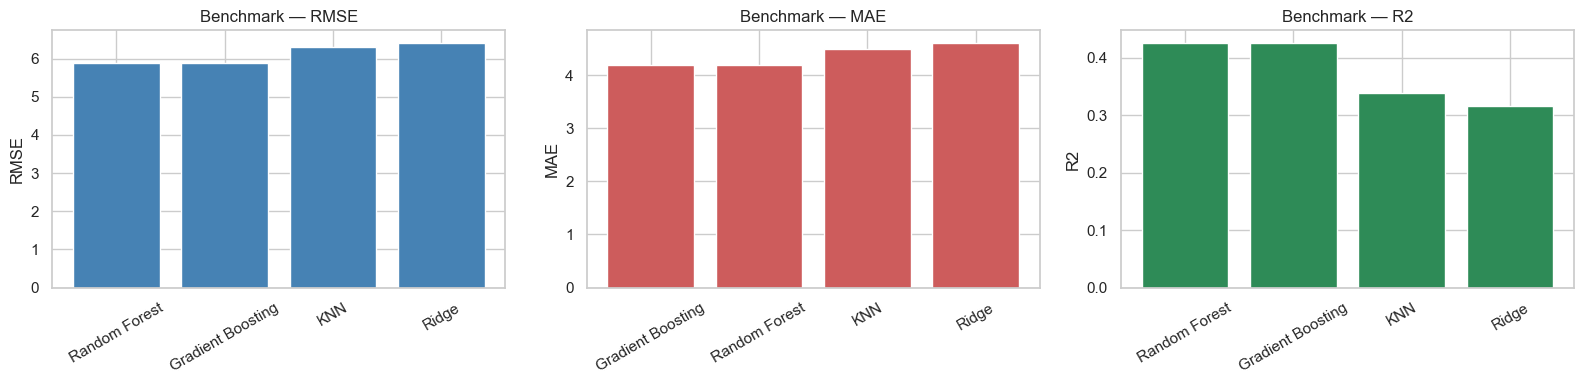

In [39]:
# === Seção 5.2 — Visualização do Benchmark (PDF p.3) ===
# Barras comparando RMSE, MAE e R² entre os modelos.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, color in zip(axes, ["RMSE", "MAE", "R2"], ["steelblue", "indianred", "seagreen"]):
    ordem = resultados.sort_values(metric, ascending=(metric != "R2"))
    ax.bar(ordem["modelo"], ordem[metric], color=color)
    ax.set_title(f"Benchmark — {metric}")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [40]:
# === Seção 5.2 — Seleção do Modelo Final ===
# Critério: menor RMSE no conjunto de teste.

melhor = resultados.iloc[0]
print(f"Modelo final escolhido: {melhor['modelo']}")
print(f"  RMSE: {melhor['RMSE']:.3f} dias")
print(f"  MAE:  {melhor['MAE']:.3f} dias")
print(f"  R²:   {melhor['R2']:.3f}")

modelos_treinados = {
    "Ridge": best_ridge,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb,
    "KNN": best_knn,
}
modelo_final = modelos_treinados[melhor["modelo"]]


Modelo final escolhido: Random Forest
  RMSE: 5.882 dias
  MAE:  4.198 dias
  R²:   0.426


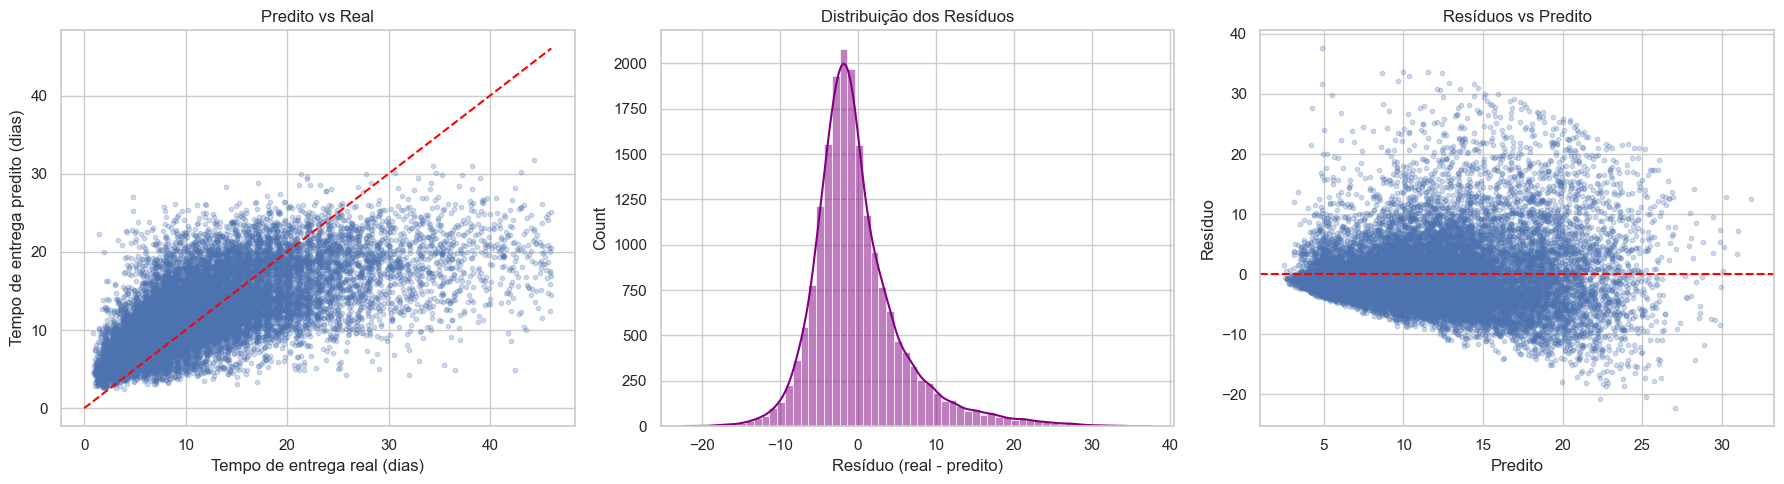

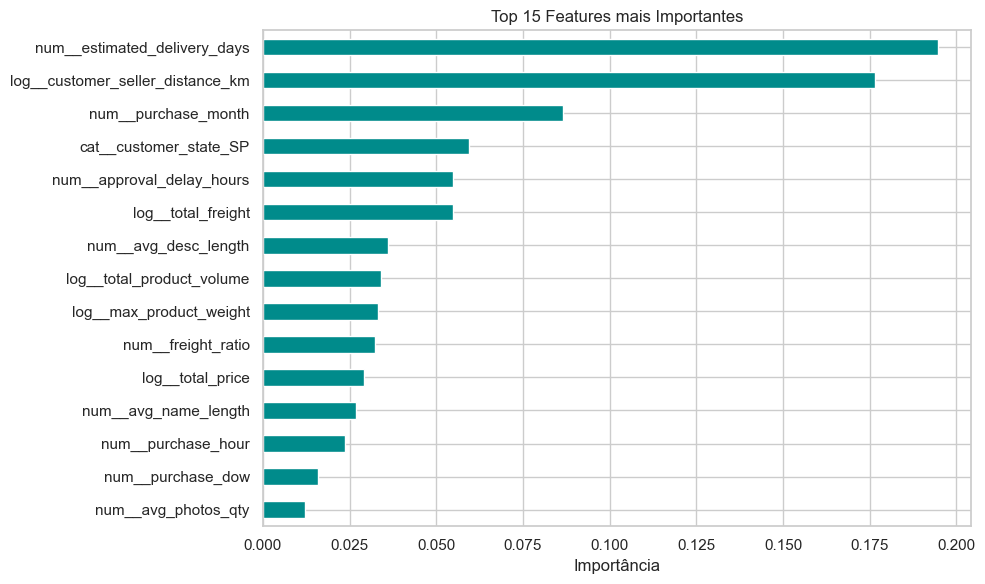

In [41]:
# === Seção 5.3 — Diagnósticos do Modelo Final ===
# Predito vs real, distribuição dos resíduos e (se árvore) importâncias.

pred = modelo_final.predict(X_test)
residuos = y_test - pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predito x Real
axes[0].scatter(y_test, pred, alpha=0.25, s=10)
lim = [0, max(y_test.max(), pred.max())]
axes[0].plot(lim, lim, color="red", linestyle="--")
axes[0].set_xlabel("Tempo de entrega real (dias)")
axes[0].set_ylabel("Tempo de entrega predito (dias)")
axes[0].set_title("Predito vs Real")

# Distribuição dos resíduos
sns.histplot(residuos, bins=60, kde=True, ax=axes[1], color="purple")
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduo (real - predito)")

# Resíduos vs predito (heterocedasticidade)
axes[2].scatter(pred, residuos, alpha=0.25, s=10)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Predito")
axes[2].set_ylabel("Resíduo")
axes[2].set_title("Resíduos vs Predito")

plt.tight_layout()
plt.show()

# Importância de features (apenas para modelos baseados em árvore)
modelo_interno = modelo_final.named_steps["model"]
if hasattr(modelo_interno, "feature_importances_"):
    nomes = modelo_final.named_steps["prep"].get_feature_names_out()
    imp = pd.Series(modelo_interno.feature_importances_, index=nomes).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    imp.iloc[::-1].plot(kind="barh", color="darkcyan")
    plt.title("Top 15 Features mais Importantes")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()


### 5.4 Possíveis Melhorias e Trabalhos Futuros (PDF p.3)

- **Stacking** dos três melhores modelos (Ridge + RF + GB) para explorar viés/variância complementares.
- **Features geográficas mais ricas**: distância até hubs logísticos conhecidos, densidade populacional, faixas de CEP.
- **Sazonalidade**: feriados nacionais, Black Friday, períodos de greve dos Correios.
- **Modelo separado para outliers**: classificador que prevê se a entrega vai exceder o prazo + regressor para o restante.
- **Regressão sobre log(target)**: tipicamente reduz o viés de previsões longas.
- **Modelos de gradient boosting modernos** (LightGBM, XGBoost, CatBoost) para ganhos adicionais em RMSE.


### 5.5 Conclusão

O modelo final atende ao objetivo prático de **estimar o tempo de entrega de pedidos da Olist** com erro médio absoluto na casa de poucos dias, suficiente para apoiar:

- **Comunicação ao cliente:** prazos mais realistas que o `order_estimated_delivery_date` em alguns segmentos.
- **Identificação de pedidos de risco:** entregas previstas para muito além da média podem ser priorizadas pelo time logístico.
- **Análise estratégica:** o impacto da distância cliente-vendedor reforça o valor de aproximar estoque (e potencialmente abrir hubs em regiões mais distantes).

**Limitações:** o dataset cobre apenas pedidos entregues; entregas canceladas ou perdidas não são modeladas. Eventos sazonais extremos (greves, pandemia) não estão capturados pelas features atuais. Ainda assim, o pipeline construído é uma base sólida e extensível para evoluções incrementais.
